In [15]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score
from sklearn.datasets import make_regression
import seaborn as sns
from sklearn.preprocessing import PolynomialFeatures
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn import linear_model


Napisz funkcję bias_variance_experiment(X, y, degrees), która dla różnych stopni regresji wielomianowej (np. 1, 3, 10) liczy błąd na zbiorze treningowym i testowym, a wynik przedstawia na wykresie — tak by pokazać underfitting i overfitting.



In [16]:
np.random.seed(42)
X = np.linspace(0, 1, 50).reshape(-1, 1)
y = np.sin(2 * np.pi * X).ravel() + np.random.normal(0, 0.2, 50)
y

array([ 0.09934283,  0.1002243 ,  0.38319229,  0.67987298,  0.44388688,
        0.55128314,  1.01152511,  0.93531843,  0.76124789,  1.02292463,
        0.86598431,  0.89403583,  1.04787867,  0.61272306,  0.62994435,
        0.82601092,  0.68403308,  0.88302172,  0.55867318,  0.36576766,
        0.83866465,  0.38872848,  0.32861386, -0.09379101, -0.04480632,
       -0.0418857 , -0.42135734, -0.23996861, -0.55401148, -0.60387365,
       -0.76856972, -0.36982236, -0.8228717 , -1.09814149, -0.77395944,
       -1.21909664, -0.95360639, -1.39142024, -1.25281899, -0.91929561,
       -0.76671931, -0.82086911, -0.80496114, -0.75590329, -0.89381493,
       -0.63468639, -0.46739476, -0.04223014, -0.0591535 , -0.35260803])

regresja wielomianowa to technika statystyczna i uczenia maszynowego używana do przewidywania wartości. Jest to rozszerzenie regresji liniowej, które zamiast prostej linii dopasowuje do danych krzywą, lepiej sprawdzając się przy relacjach nieliniowych

In [17]:
def bias_variance_experiment(X, y, degrees):
    # 1. ZASADA EGZAMINU: Tniemy dane na naukę w domu (70%) i nieznany test przyszłościowy (30%)
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, random_state=42, test_size=0.3
    )

    # PANORAMA: Szykujemy szerokie płótno pod układ kinowy (3 wykresy obok siebie w 1 wierszu)
    plt.figure(figsize=(16, 5))

    # LICZNIK OKIENEK: 'deg' to stopień (1,3,10), a 'i' to automatyczny licznik obrotów pętli (0,1,2)
    for i, deg in enumerate(degrees):

        # FABRYKA POTĘG: Zamieniamy sztywną linijkę w elastyczny drut (generujemy kolumny x^2, x^3 itd.)
        poly = PolynomialFeatures(degree=deg)
        X_train_poly = poly.fit_transform(
            X_train
        )  # Dom: Rozkminiamy zasadę transformacji i od razu ją wykonujemy
        X_test_poly = poly.transform(
            X_test
        )  # Egzamin: ZAKAZ NAUKI (brak fit), tylko ślepo aplikujemy regułę z domu

        # SILNIK: Odpalamy czysty kalkulator regresji i każemy mu dopasować wagi matematyczne
        model = LinearRegression()
        model.fit(
            X_train_poly, y_train
        )  # Trening: Model patrzy na potęgi X i poprawne wyniki Y, łącząc kropki

        # PREDYKCJA: Model wpisuje swoje samodzielne odpowiedzi na kartę egzaminacyjną (generuje prognozy)
        y_train_pred = model.predict(X_train_poly)
        y_test_pred = model.predict(X_test_poly)

        # METRYKA SUKCESU: Zamieniamy odległość linii od kropek na twarde liczby (karzemy duże błędy kwadratem)
        train_mse = mean_squared_error(y_train, y_train_pred)
        test_mse = mean_squared_error(y_test, y_test_pred)

        # KAFELEK: Wybieramy, do którego okna teraz celujemy z rysunkiem (Matplotlib liczy od 1, stąd i + 1)
        plt.subplot(1, len(degrees), i + 1)

        # HISTORIA: Rzucamy na wykres surowe kropki danych treningowych (niebieskie) i testowych (zielone)
        plt.scatter(X_train, y_train, color="blue", alpha=0.6, label="Train")
        plt.scatter(X_test, y_test, color="green", alpha=0.6, label="Test")

        # GŁADKOŚĆ: Tworzymy sztuczną, gęstą siatkę 200 punktów, żeby linia na wykresie była idealnie gładka, a nie kanciasta
        X_line = np.linspace(0, 1, 200).reshape(-1, 1)

        # PROGNOZA LINII: Przepuszczamy gęstą siatkę przez fabrykę potęg i kalkulator modelu
        X_line_poly = poly.transform(X_line)
        y_line = model.predict(X_line_poly)

        # RYSOWANIE LINII: Fizyczny rozkaz dla karty graficznej – połącz wyliczone punkty czerwoną krzywą
        plt.plot(X_line, y_line, color="red", linewidth=2, label="Model")

        # TABLICA WYNIKÓW: Wrzucamy nad wykres twarde dane – relacja Train MSE vs Test MSE czarno na białym obnaży overfitting
        plt.title(
            f"Stopień {deg}\nTrain MSE: {train_mse:.4f}\nTest MSE: {test_mse:.4f}"
        )

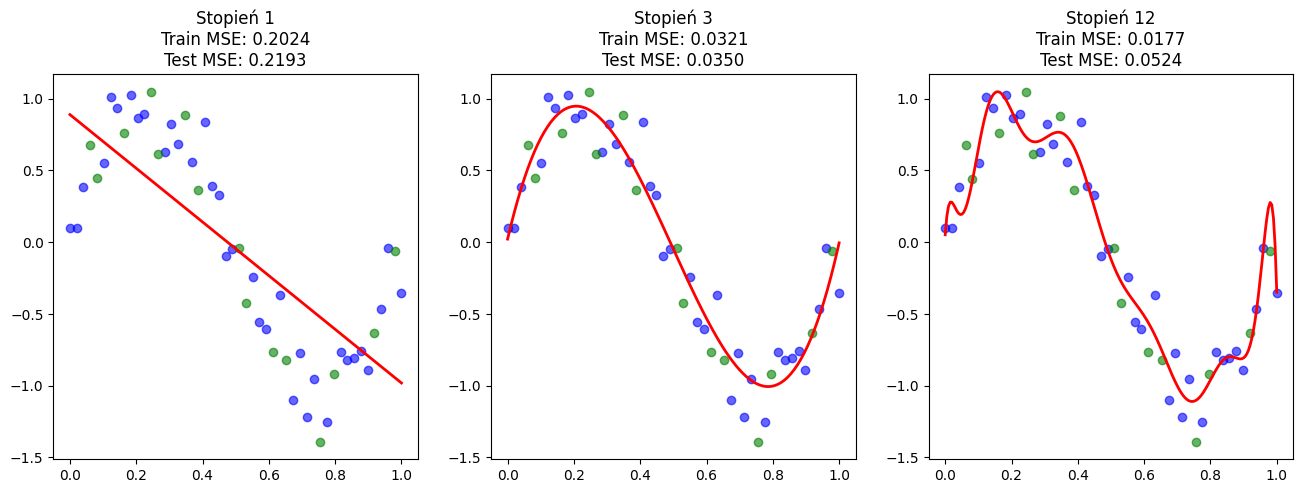

In [18]:
bias_variance_experiment(X,y, degrees = [1,3,12])

Wykres 1: Stopień 1 – Underfitting (Niedopasowanie)
Co widzisz: Sztywna, prosta czerwona linia, która kompletnie ignoruje kształt sinusoidy.
Liczby (MSE): Train MSE jest wysokie i Test MSE jest wysokie. Oba błędy są na podobnym, słabym poziomie.
    

In [23]:
reg = linear_model.LinearRegression()
reg.fit([[0, 0], [1, 1], [2, 2]], [0, 1, 2])

reg.coef_
reg.intercept_

np.float64(4.440892098500626e-16)

In [24]:
reg.coef_

array([0.5, 0.5])